In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re 
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\anjal\OneDrive\Quora_question_pair\Data\train.csv")

In [3]:
newdf = df.copy()
newdf

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404285,404285,433578,379845,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404286,404286,18840,155606,Do you believe there is life after death?,Is it true that there is life after death?,1
404287,404287,537928,537929,What is one coin?,What's this coin?,0
404288,404288,537930,537931,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [4]:
newdf = df.sample(30000,random_state=2)

In [5]:
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [6]:
def preprocess(q):
    q = str(q).lower().strip()

    #replace special characters with their string equivalents

    q = q.replace('%','percent')
    q = q.replace('$','dollar')
    q = q.replace('₹','rupee')
    q = q.replace('€','euro')
    q = q.replace('@','at')

    # the pattern '[math]' appears around 900 times in the whole dataset
    q = q.replace('[math]','')

    # replacing some numbers with string euivalents 
    q = q.replace('000,000,000','b')
    q = q.replace('000,000','m')
    q = q.replace('000','k')
    q = re.sub(r'([0-9]+)000000000',r'\1b',q)
    q = re.sub(r'([0-9]+)000000',r'\1m',q)
    q = re.sub(r'([0-9]+)000',r'\1k',q)

    # decontracting words

    # Source - https://stackoverflow.com/a/19794953

    contractions = { 
        "ain't": "am not / are not / is not / has not / have not",
        "aren't": "are not / am not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "could've": "could have",
        "couldn't": "could not",
        "couldn't've": "could not have",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hadn't've": "had not have",
        "hasn't": "has not",
        "haven't": "have not",
        "he'd": "he had / he would",
        "he'd've": "he would have",
        "he'll": "he shall / he will",
        "he'll've": "he shall have / he will have",
        "he's": "he has / he is",
        "how'd": "how did",
        "how'd'y": "how do you",
        "how'll": "how will",
        "how's": "how has / how is / how does",
        "I'd": "I had / I would",
        "I'd've": "I would have",
        "I'll": "I shall / I will",
        "I'll've": "I shall have / I will have",
        "I'm": "I am",
        "I've": "I have",
        "isn't": "is not",
        "it'd": "it had / it would",
        "it'd've": "it would have",
        "it'll": "it shall / it will",
        "it'll've": "it shall have / it will have",
        "it's": "it has / it is",
        "let's": "let us",
        "ma'am": "madam",
        "mayn't": "may not",
        "might've": "might have",
        "mightn't": "might not",
        "mightn't've": "might not have",
        "must've": "must have",
        "mustn't": "must not",
        "mustn't've": "must not have",
        "needn't": "need not",
        "needn't've": "need not have",
        "o'clock": "of the clock",
        "oughtn't": "ought not",
        "oughtn't've": "ought not have",
        "shan't": "shall not",
        "sha'n't": "shall not",
        "shan't've": "shall not have",
        "she'd": "she had / she would",
        "she'd've": "she would have",
        "she'll": "she shall / she will",
        "she'll've": "she shall have / she will have",
        "she's": "she has / she is",
        "should've": "should have",
        "shouldn't": "should not",
        "shouldn't've": "should not have",
        "so've": "so have",
        "so's": "so as / so is",
        "that'd": "that would / that had",
        "that'd've": "that would have",
        "that's": "that has / that is",
        "there'd": "there had / there would",
        "there'd've": "there would have",
        "there's": "there has / there is",
        "they'd": "they had / they would",
        "they'd've": "they would have",
        "they'll": "they shall / they will",
        "they'll've": "they shall have / they will have",
        "they're": "they are",
        "they've": "they have",
        "to've": "to have",
        "wasn't": "was not",
        "we'd": "we had / we would",
        "we'd've": "we would have",
        "we'll": "we will",
        "we'll've": "we will have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what'll": "what shall / what will",
        "what'll've": "what shall have / what will have",
        "what're": "what are",
        "what's": "what has / what is",
        "what've": "what have",
        "when's": "when has / when is",
        "when've": "when have",
        "where'd": "where did",
        "where's": "where has / where is",
        "where've": "where have",
        "who'll": "who shall / who will",
        "who'll've": "who shall have / who will have",
        "who's": "who has / who is",
        "who've": "who have",
        "why's": "why has / why is",
        "why've": "why have",
        "will've": "will have",
        "won't": "will not",
        "won't've": "will not have",
        "would've": "would have",
        "wouldn't": "would not",
        "wouldn't've": "would not have",
        "y'all": "you all",
        "y'all'd": "you all would",
        "y'all'd've": "you all would have",
        "y'all're": "you all are",
        "y'all've": "you all have",
        "you'd": "you had / you would",
        "you'd've": "you would have",
        "you'll": "you shall / you will",
        "you'll've": "you shall have / you will have",
        "you're": "you are",
        "you've": "you have"
        }
    
    q_contracted = []
    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_contracted.append(word)

    q = ' '.join(q_contracted) 
    q = q.replace("ve","have")
    q = q.replace("n't","not")
    q = q.replace("re","are")
    q = q.replace("ll","will")


    # remove html tags
    q = BeautifulSoup(q) 
    q = q.get_text()  

    # remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern,' ',q).strip()

    return q


In [7]:
newdf['question1'] = newdf['question1'].apply(preprocess)
newdf['question2'] = newdf['question2'].apply(preprocess)


In [8]:
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0


In [9]:
#Feature Engineering
newdf['q1_len'] = newdf['question1'].str.len()
newdf['q2_len'] = newdf['question2'].str.len()

In [10]:
newdf['q1_num_words'] = newdf['question1'].apply(lambda row: len(row.split(" ")))
newdf['q2_num_words'] = newdf['question2'].apply(lambda row: len(row.split(" ")))
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9


In [ ]:
def common_words(q1,q2):
    w1 = set(q1.lower().split())
    w2 = set(q2.lower().split())
    return len(w1 & w2)

In [12]:
newdf['word_common'] = newdf.apply(common_words,axis = 1)
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13,12
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16,8
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21,4
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32,1
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9,3


In [13]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(),row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [14]:
newdf['word_total'] = newdf.apply(total_words,axis=1)
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13,12,26
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16,8,24
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21,4,38
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32,1,34
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9,3,13


In [15]:
newdf['word_share'] = round(newdf['word_common']/newdf['word_total'],2)
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16,8,24,0.33
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21,4,38,0.11
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32,1,34,0.03
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9,3,13,0.23


In [16]:
# Advanced features
from nltk.corpus import stopwords

def fetch_token_features(row):
    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Coverting the sentence into tokens
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features
    
    # Get the non stopwords in questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the stopwords in questions

    q1_stops  = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_stops  = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the common non-stopwords from question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from question pair
    common_stop_count = len(q1_words.intersection(q2_words))

    # Get the common tokens from question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min(len(q1_words),len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words),len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops),len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops),len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens),len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens),len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [17]:
token_features = newdf.apply(fetch_token_features,axis = 1)

newdf["cwc_min"] = list(map(lambda x : x[0], token_features))
newdf["cwc_max"] = list(map(lambda x : x[1], token_features))
newdf["csc_min"] = list(map(lambda x : x[2], token_features))
newdf["csc_max"] = list(map(lambda x : x[3], token_features))
newdf["ctc_min"] = list(map(lambda x : x[4], token_features))
newdf["ctc_max"] = list(map(lambda x : x[5], token_features))
newdf["last_word_eq"] = list(map(lambda x : x[6], token_features))
newdf["first_word_eq"] = list(map(lambda x : x[7], token_features))




In [18]:
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13,...,26,0.46,0.874989,0.874989,0.874989,0.874989,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16,...,24,0.33,0.666644,0.399992,0.666644,0.399992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21,...,38,0.11,0.000000,0.000000,0.000000,0.000000,0.149999,0.115384,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32,...,34,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9,...,13,0.23,0.749981,0.599988,0.749981,0.599988,0.599988,0.333330,1.0,0.0


In [19]:
import distance 
def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    # converting the sentence into tokens 

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    #Absolute length features 
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #average taken length of both questions
    length_features[1] = (len(q1_tokens) - len(q2_tokens))/2
     
    strs = list(distance.lcsubstrings(q1,q2))
    length_features[2] = len(strs[0])/ (min(len(q1),len(q2)) + 1)

    return length_features

In [20]:
length_features = newdf.apply(fetch_length_features,axis = 1)

newdf['abs_len_diff'] = list(map(lambda x: x[0],length_features))
newdf['mean_len'] = list(map(lambda x: x[1],length_features))
newdf['longest_substr_ratio'] = list(map(lambda x: x[2],length_features))

In [21]:
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13,...,0.874989,0.874989,0.874989,0.923070,0.923070,1.0,1.0,0.0,0.0,0.858974
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16,...,0.399992,0.666644,0.399992,0.583328,0.466664,1.0,1.0,3.0,-1.5,0.215686
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21,...,0.000000,0.000000,0.000000,0.149999,0.115384,0.0,0.0,6.0,3.0,0.046729
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,-8.5,0.050847
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9,...,0.599988,0.749981,0.599988,0.599988,0.333330,1.0,0.0,4.0,-2.0,0.542857


In [22]:
# fuzzy features

from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
     q1 = row['question1']
     q2 = row['question2']

     fuzzy_features = [0.0]*4

     #fuzzz ratio
     fuzzy_features[0] = fuzz.QRatio(q1,q2)

     #fuzz_partial_ratio
     fuzzy_features[1] = fuzz.partial_ratio(q1,q2)

     #token_sort_ratio
     fuzzy_features[2] = fuzz.token_sort_ratio(q1,q2)

     #token_set_ratio
     fuzzy_features[3] = fuzz.token_set_ratio(q1,q2)

     return fuzzy_features

In [23]:
fuzzy_fetaures = newdf.apply(fetch_fuzzy_features,axis=1)

newdf['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_fetaures))
newdf['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_fetaures))
newdf['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_fetaures))
newdf['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_fetaures))

In [24]:
newdf.shape

(30000, 28)

In [25]:
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,77,78,13,13,...,0.923070,1.0,1.0,0.0,0.0,0.858974,99,99,99,99
115086,115086,187729,187730,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...,0,50,58,13,16,...,0.466664,1.0,1.0,3.0,-1.5,0.215686,70,68,62,74
327711,327711,454161,454162,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...,0,106,123,28,21,...,0.115384,0.0,0.0,6.0,3.0,0.046729,26,30,32,38
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,149,14,32,...,0.000000,0.0,0.0,17.0,-8.5,0.050847,28,41,23,29
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...,0,34,50,5,9,...,0.333330,1.0,0.0,4.0,-2.0,0.542857,55,70,45,69


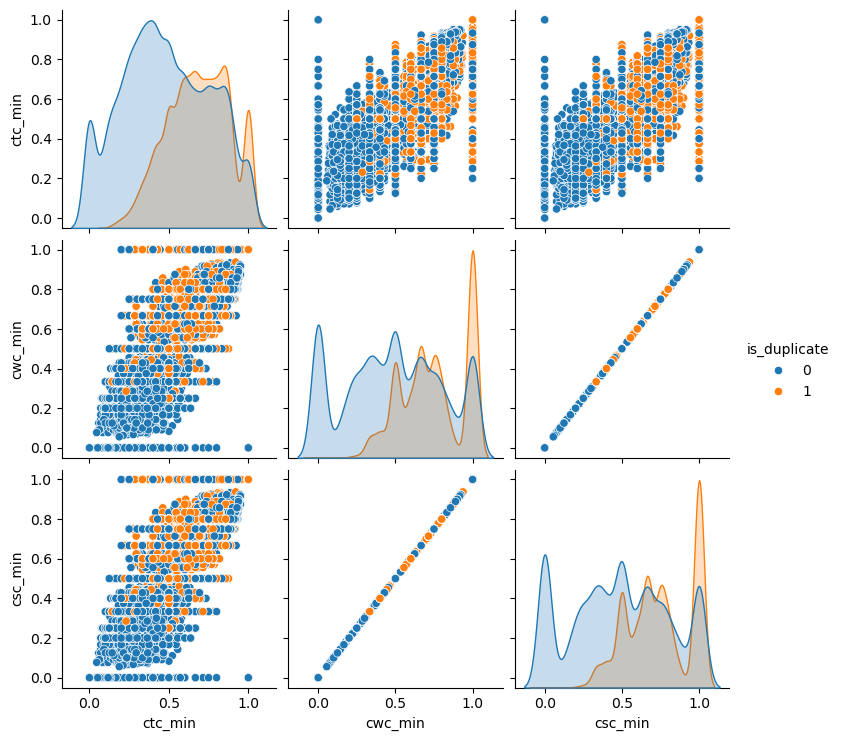

In [26]:
sns.pairplot(newdf[['ctc_min','cwc_min','csc_min','is_duplicate']],hue='is_duplicate')

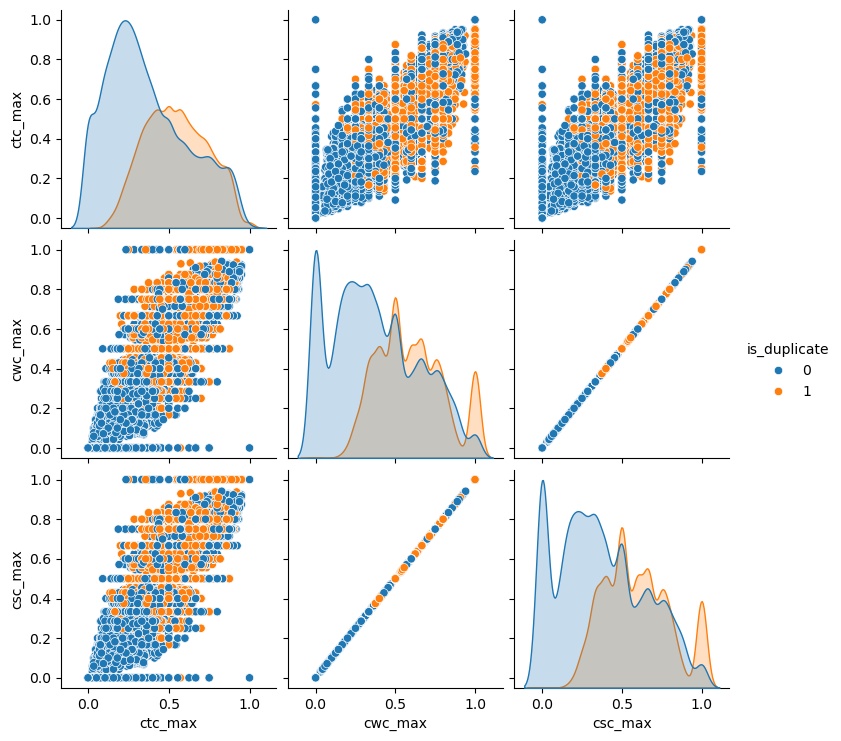

In [27]:
sns.pairplot(newdf[['ctc_max','cwc_max','csc_max','is_duplicate']],hue='is_duplicate')

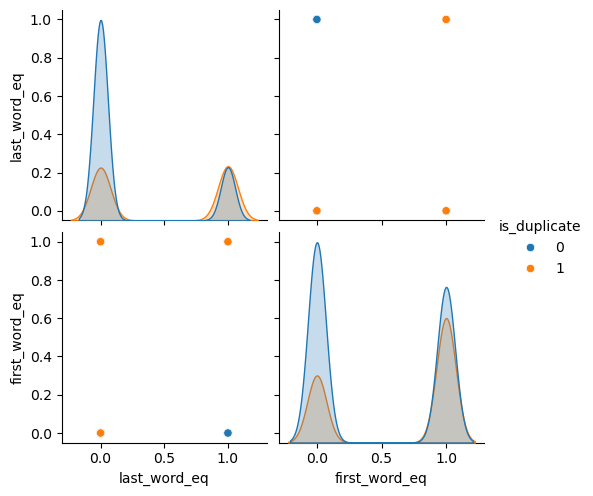

In [28]:
sns.pairplot(newdf[['last_word_eq','first_word_eq','is_duplicate']],hue='is_duplicate')

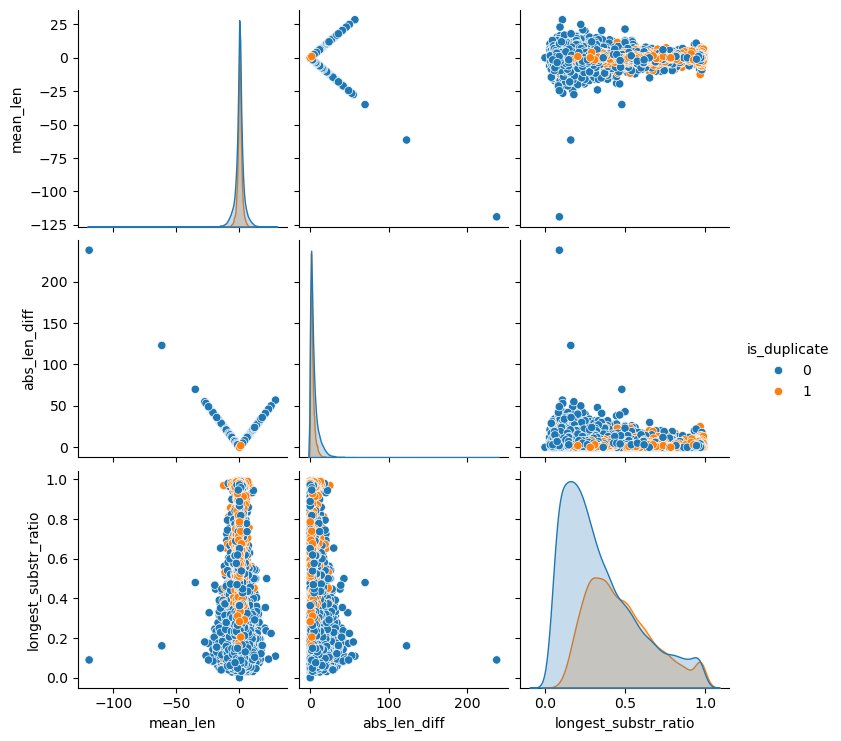

In [29]:
sns.pairplot(newdf[['mean_len','abs_len_diff','longest_substr_ratio','is_duplicate']],hue='is_duplicate')

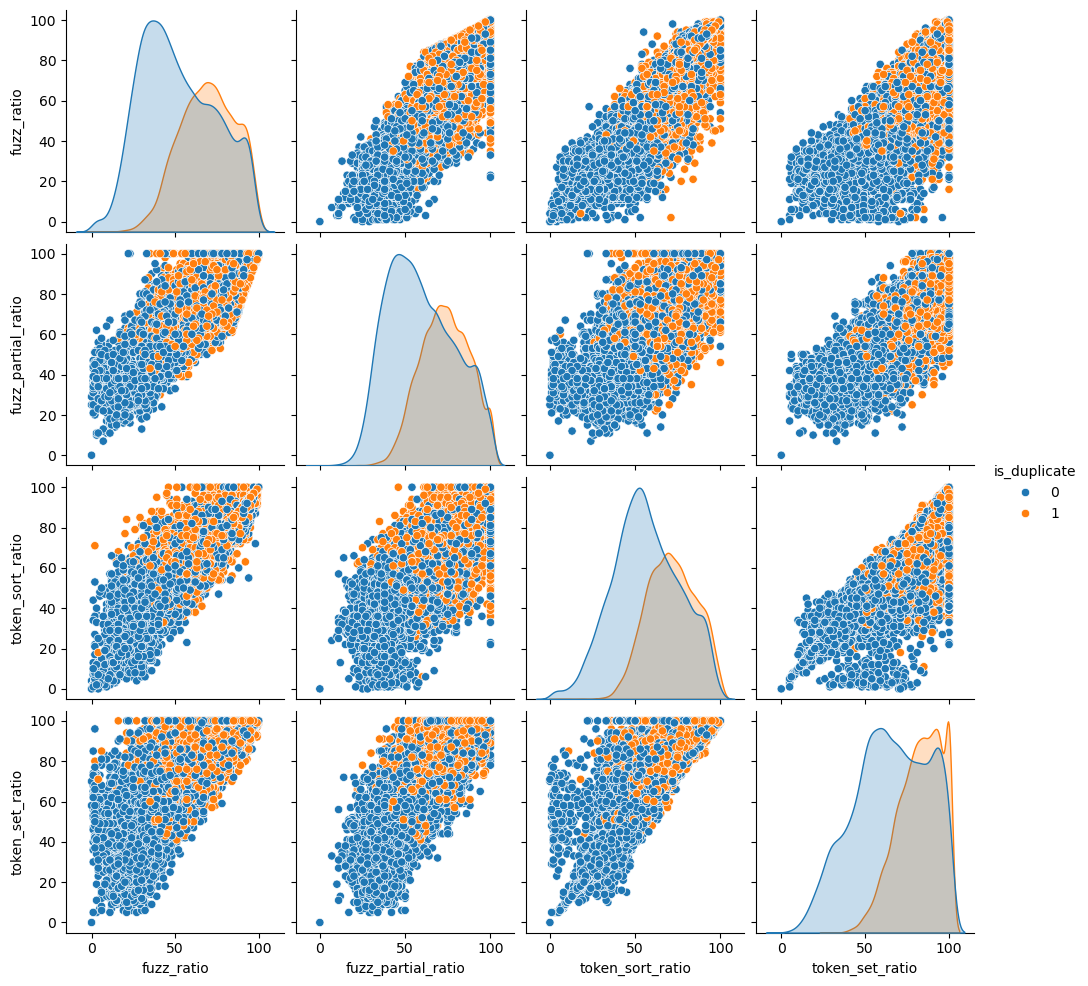

In [30]:
sns.pairplot(newdf[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio','is_duplicate']],hue='is_duplicate')

In [31]:
from sklearn.preprocessing import MinMaxScaler
X = MinMaxScaler().fit_transform(newdf[['cwc_min','cwc_max','csc_min','csc_max','ctc_min','ctc_max','last_word_eq','first_word_eq','abs_len_diff',
       'mean_len', 'longest_substr_ratio', 'fuzz_ratio', 'fuzz_partial_ratio',
       'token_sort_ratio', 'token_set_ratio']])
y = newdf['is_duplicate'].values

In [32]:
#using TSNE for dimensionality reduction for 15 features generated after cleaning the data to 4 dimension
from sklearn.manifold import TSNE

tsne2d = TSNE(n_components = 2,
              init = 'random',#pca
              random_state = 101,
              method = 'barnes_hut',
              max_iter = 1000,
              verbose = 2,
              angle= 0.5
              ).fit_transform(X)



[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.057s...
[t-SNE] Computed neighbors for 30000 samples in 3.893s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

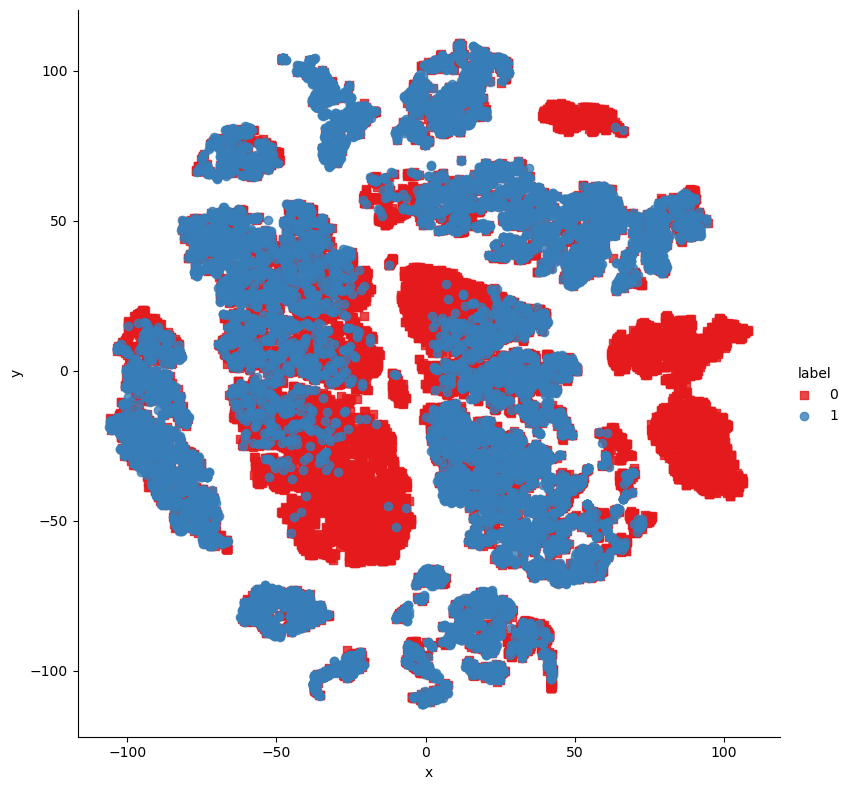

In [33]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False, height=8,palette="Set1",markers=['s','o'])

In [34]:
tsne3d = TSNE(
    n_components=3,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    max_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.060s...
[t-SNE] Computed neighbors for 30000 samples in 3.821s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [35]:
import sys
!{sys.executable} -m pip install plotly

In [36]:
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py
py.init_notebook_mode(connected=True)

trace1 = go.Scatter3d(
    x=tsne3d[:,0],
    y=tsne3d[:,1],
    z=tsne3d[:,2],
    mode='markers',
    marker=dict(
        sizemode='diameter',
        color = y,
        colorscale = 'Portland',
        colorbar = dict(title = 'duplicate'),
        line=dict(color='rgb(255, 255, 255)'),
        opacity=0.75
    )
)

data=[trace1]
layout=dict(height=800, width=800, title='3d embedding with engineered features')
fig=dict(data=data, layout=layout)
py.iplot(fig, filename='3DBubble')

In [37]:


quesdf = newdf[['question1','question2']]
quesdf.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to inhavest what should ...,i am quite poor and i want to be havery rich ...
327711,i am from india and lihave abroad i met a guy...,t i e t to thapar unihaversity to thapar uniha...
367788,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the areason behind the bhopal gas tra...


In [38]:

finaldf = newdf.drop(columns=['id','qid1','qid2','question1','question2'])
print(finaldf.shape)
finaldf.head()

(30000, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,77,78,13,13,12,26,0.46,0.874989,0.874989,...,0.923070,1.0,1.0,0.0,0.0,0.858974,99,99,99,99
115086,0,50,58,13,16,8,24,0.33,0.666644,0.399992,...,0.466664,1.0,1.0,3.0,-1.5,0.215686,70,68,62,74
327711,0,106,123,28,21,4,38,0.11,0.000000,0.000000,...,0.115384,0.0,0.0,6.0,3.0,0.046729,26,30,32,38
367788,0,58,149,14,32,1,34,0.03,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,-8.5,0.050847,28,41,23,29
151235,0,34,50,5,9,3,13,0.23,0.749981,0.599988,...,0.333330,1.0,0.0,4.0,-2.0,0.542857,55,70,45,69


In [39]:

from sklearn.feature_extraction.text import CountVectorizer
# merge texts
ques = list(quesdf['question1']) + list(quesdf['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(ques).toarray(),2)

In [40]:

temp_df1 = pd.DataFrame(q1_arr, index= quesdf.index)
temp_df2 = pd.DataFrame(q2_arr, index= quesdf.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [41]:

finaldf = pd.concat([finaldf, temp_df], axis=1)
print(finaldf.shape)
finaldf.head()

(30000, 6023)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,77,78,13,13,12,26,0.46,0.874989,0.874989,...,0,0,0,0,0,0,0,0,0,0
115086,0,50,58,13,16,8,24,0.33,0.666644,0.399992,...,0,0,0,0,0,0,0,0,0,0
327711,0,106,123,28,21,4,38,0.11,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
367788,0,58,149,14,32,1,34,0.03,0.000000,0.000000,...,0,0,0,1,0,0,0,0,0,0
151235,0,34,50,5,9,3,13,0.23,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [42]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(finaldf.iloc[:,1:].values,finaldf.iloc[:,0].values,test_size=0.2,random_state=1)

In [43]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7823333333333333

In [44]:

from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred1 = xgb.predict(X_test)
accuracy_score(y_test,y_pred1)

0.788

In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
# for random forest model
confusion_matrix(y_test,y_pred)

array([[3262,  550],
       [ 756, 1432]])

In [47]:
# for xgboost model
confusion_matrix(y_test,y_pred1)

array([[3218,  594],
       [ 678, 1510]])

In [ ]:
def query_point_creator(q1,q2):
    
    input_query = []
    
    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)
    
    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))
    
    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))
    
    input_query.append(common_words(q1,q2))
    input_query.append(total_words(q1,q2))
    input_query.append(round(common_words(q1,q2)/total_words(q1,q2),2))
    
    # fetch token features
    token_features = fetch_token_features(q1,q2)
    input_query.extend(token_features)
    
    # fetch length based features
    length_features = fetch_length_features(q1,q2)
    input_query.extend(length_features)
    
    # fetch fuzzy features
    fuzzy_features = fetch_fuzzy_features(q1,q2)
    input_query.extend(fuzzy_features)
    
    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()
    
    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()
    
    
    
    return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [49]:

q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'

In [50]:

rf.predict(query_point_creator(q1,q2))

TypeError: common_words() takes 1 positional argument but 2 were given